# Synthetic antiferromagnet
In this example we simulate a synthetic ferromagnet, consisting of two ferromagnetic layers coupled by the RKKY interaction, under the influence of an external field in y-direction. We neglect the influence of the demagnetization field and pin the upper layer in the x-direction with a strong uniaxiatial ansisotropy field. Considering thin layers with a homogeneous magnetization in z-direction, the y-component of the magnetization in the bottom layer should follow the field as
$$m_y(H_y) = \sin(\arctan{[}t * H_y / A_i{]})$$
with $t$ being the thickness of the bottom layer and $A_i$ being the interlayer exchange coupling strength in [J/m$^2$].

## Simulation
### Import libraries and set precision

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from scipy import constants

import neuralmag as nm

# set to double precision for convergence
nm.config.dtype = "float64"

pv.set_jupyter_backend("static")

2025-05-12 18:02:15 NeuralMag:INFO [NeuralMag] Version 0.9.1
2025-05-12 18:02:16 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-05-12 18:02:16 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


### Set up mesh, state and geometry
We prepare a mesh with 3 layers to describe the magnetic trilayer structure. The middle layer should act as a nonmagnetic spacer layer. Therefore, we set the density field ```state.rho``` to machine epsilon (NeuralMag does not support 0 density since this will lead to division-by-zero errors).

In [2]:
# setup mesh and state
mesh = nm.Mesh((10, 10, 3), (1e-9, 1e-9, 1e-9))
state = nm.State(mesh)

# set empty spacer layer
rho = np.ones(mesh.n)
rho[:, :, 1] = state.eps
state.rho = nm.CellFunction(state, tensor=state.tensor(rho))

2025-05-12 18:02:16 NeuralMag:INFO [Mesh] 3D, 10 x 10 x 3 (size = 1e-09 x 1e-09 x 1e-09)
2025-05-12 18:02:16 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-05-12 18:02:16 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float64, backend = jax)


### Set up material
We set the material parameters Ms, A and alpha as constants since they are assumed to be equal in the both ferromagnetic layers. We could set these parameters to zero in the spacer layer. However, since the field contributions only consider the magnetic region ```state.rho``` this would lead to an unnecessary memory overhead.

We set the interface coupling constant ```iA``` as a constant -0.5 mJ/m to propote antiferromagnetic coupling. The actual interfaces to be coupled will be set in the ```InterlayerExchangeField``` class.

The uniaxial anisotropy is to 10 mJ/m$^3$ only in top ferromagnetic layer. As for the magnetic region ```rho```, we prepare the tensor using NumPy before initializing the actual function object.

In [3]:
# setup material and m0
state.material.Ms = 1.0 / constants.mu_0
state.material.A = 1.3e-11
state.material.alpha = 1.0
state.material.iA = nm.Function(state, "ccn").fill(-0.5e-3, expand=True)

# set Ku to 1e7 in upper layer and keep it zero everywhere else
Ku = np.zeros(mesh.n)
Ku[:, :, 2:] = 1e7
state.material.Ku = nm.CellFunction(state, tensor=state.tensor(Ku))
state.material.Ku_axis = [1, 0, 0]

### Set initial magnetization and plot result

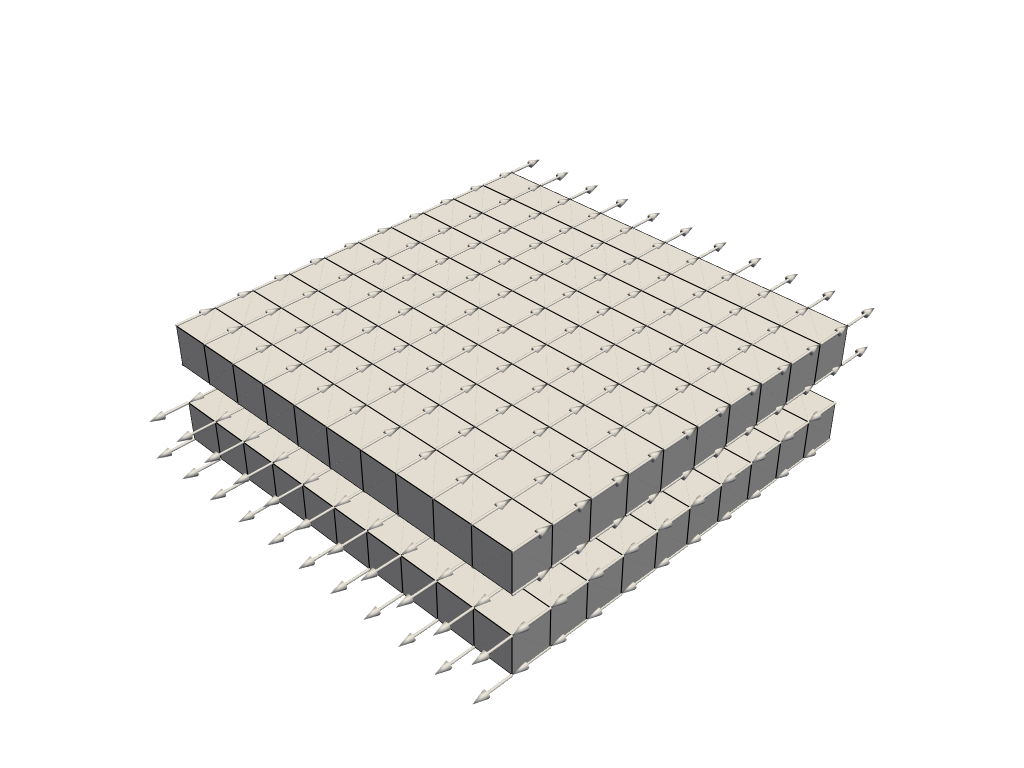

In [4]:
# initialize magnetization
m = np.zeros((11, 11, 4, 3))
m[:, :, :, 0] = 1.0
m[:, :, 2:, 0] = -1.0
state.m = nm.VectorFunction(state, tensor=state.tensor(m))

# write initial magnetization and
state.write_vti(["m", "rho"], "synthetic_antiferromagnet/m0.vti")
mesh = pv.read("synthetic_antiferromagnet/m0.vti")
thresholded_mesh = mesh.threshold(value=0.5, scalars="rho")
glyphs = mesh.glyph(orient="m", scale="m", factor=1e-9)
p = pv.Plotter()
p.add_mesh(
    thresholded_mesh,
    color="white",
    lighting=True,
    show_edges=True,
)
p.add_mesh(glyphs, color="white", lighting=True, smooth_shading=True)
p.show()

### Register effective field contributions
For this example we only consider the exchange field, the interlayer exchange between node layer 1 and 2 to model the RKKY coupling, a uniaxial anisotropy to pin the bottom layer and an external field varying in time in order to simulate the hysteresis of the synthetic antiferromagnet.

In [5]:
# register effective field contributions
nm.ExchangeField().register(state, "exchange")
nm.InterlayerExchangeField(1, 2).register(state, "rkky")
nm.ExternalField(lambda t: t * state.tensor([0, 5.0 / constants.mu_0 / 5e-9, 0])).register(state, "external")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("exchange", "rkky", "external", "aniso").register(state)

2025-05-12 18:02:16 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-05-12 18:02:16 NeuralMag:INFO [InterlayerExchangeField] Register state methods (field: 'h_rkky', energy: 'E_rkky')
2025-05-12 18:02:16 NeuralMag:INFO [ExternalField] Register state methods (field: 'h_external', energy: 'E_external')
2025-05-12 18:02:16 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-05-12 18:02:16 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


### Register dynamic attribute for logging
In order to log the tilting of the bottom (soft) magnetic layer under the influence of the external field, we register a dynamic attribute that averages the magnetization over the bottom layer.

In [6]:
state.m_bottom = lambda m: nm.config.backend.mean(m[:, :, :2, :], axis=(0, 1, 2))

### Perform time integration to simulate hysteresis

In [7]:
llg = nm.LLGSolver(state)
logger = nm.ScalarLogger("synthetic_antiferromagnet/log.dat", ["h_external", "m_bottom"])
while state.t < 5e-9:
    logger.log(state)
    llg.step(1e-10)

2025-05-12 18:02:16 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-05-12 18:02:17 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 0s
2025-05-12 18:02:30 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 1e-10s
2025-05-12 18:02:30 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 2e-10s
2025-05-12 18:02:31 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 3e-10s
2025-05-12 18:02:32 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 4e-10s
2025-05-12 18:02:33 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 5e-10s
2025-05-12 18:02:34 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 6e-10s
2025-05-12 18:02:35 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 7e-10s
2025-05-12 18:02:35 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 8e-10s
2025-05-12 18:02:36 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 9e-10s
2025-05-12 18:02:37 NeuralMag:INFO [LLGSolverJAX] Step: dt = 1e-10s, t = 1e-09s
2025-05-12 18:02:38 NeuralMag:INFO [LLGSolverJAX] 

### Plot the solution

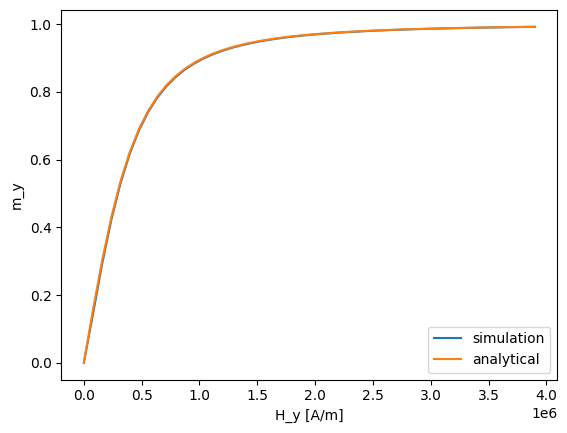

In [8]:
# Define analytical solution
def m_y(H_y):
    return np.sin(np.arctan(1e-9 * H_y / 0.0005))


data = np.loadtxt("synthetic_antiferromagnet/log.dat")
plt.plot(data[:, 1], data[:, 4], label="simulation")
plt.plot(data[:, 1], m_y(data[:, 1]), label="analytical")
plt.legend(loc="lower right")
plt.xlabel("H_y [A/m]")
plt.ylabel("m_y");